# ARTI 308 – Lab 5 (Rewritten for BNPL Dataset)
## Repayment Status Classification


In [ ]:
import pandas as pd
import numpy as np

df_encoded = pd.get_dummies(df_fe, drop_first=True)

drop_cols = [c for c in [target_col, 'Transaction_ID'] if c in df_encoded.columns]
X = df_encoded.drop(columns=drop_cols).values.astype(float)
y = df_encoded[target_col].values

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1.0 
X_scaled = (X - X_mean) / X_std

np.random.seed(42)
indices = np.random.permutation(len(X_scaled))
split_point = int(0.8 * len(X_scaled))

train_idx, test_idx = indices[:split_point], indices[split_point:]
X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

def predict_knn(X_train, y_train, X_test, k=5):
    preds = []
    for row in X_test:
        distances = np.sqrt(np.sum((X_train - row)**2, axis=1))
        k_indices = np.argsort(distances)[:k]
        k_nearest_labels = y_train[k_indices].astype(int)
        preds.append(np.bincount(k_nearest_labels).argmax())
    return np.array(preds)

y_pred = predict_knn(X_train, y_train, X_test, k=5)

accuracy = np.mean(y_pred == y_test)
conf_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])

print(f"Accuracy: {accuracy:.4f}")
print(conf_matrix)

In [2]:
DATA_PATH = 'bnpl_dataset.csv'
df = pd.read_csv(DATA_PATH)
df.head(10)

,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,56,Male,32293,353,Beauty,Sezzle,249,Defaulted
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,46,Male,72774,354,Groceries,Affirm,188,Paid On Time
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,32,Male,82207,630,Travel,Sezzle,1610,Paid On Time
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,60,Male,92498,470,Fashion,Sezzle,120,Paid On Time
4,3f1b1928-09ca-4d06-8ec3-4efd3468d0ec,25,Male,32060,502,Travel,Klarna,1849,Paid On Time
5,f99db9dc-9e5c-40d1-918a-ecd3469e8c17,38,Female,94833,779,Travel,Klarna,1112,Paid On Time
6,085eae6d-ec9e-4ffd-9d8e-f7629c6db760,56,Female,89772,403,Travel,Klarna,418,Paid On Time
7,1d9eb495-215e-415e-8b2d-411be80398ef,36,Male,82341,731,Travel,Klarna,2117,Paid On Time
8,71a12b8c-b969-432d-9470-4eb4cb89a066,40,Female,80517,669,Home & Furniture,Sezzle,286,Paid On Time
9,f8fd5853-7121-4ee4-aec8-8559b8802bf4,28,Female,108929,359,Beauty,Klarna,244,Defaulted


In [3]:
print('Shape:', df.shape)
print('\nMissing values per column:')
display(df.isna().sum().to_frame('missing_count').T)
print('\nDuplicate rows:', df.duplicated().sum())

Shape: (50000, 9)

Missing values per column:


,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status
missing_count,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


In [4]:
target_col = 'Repayment_Status'
df[target_col].value_counts()

Repayment_Status
Paid On Time    37612
Late Payment     8009
Defaulted        4379
Name: count, dtype: int64

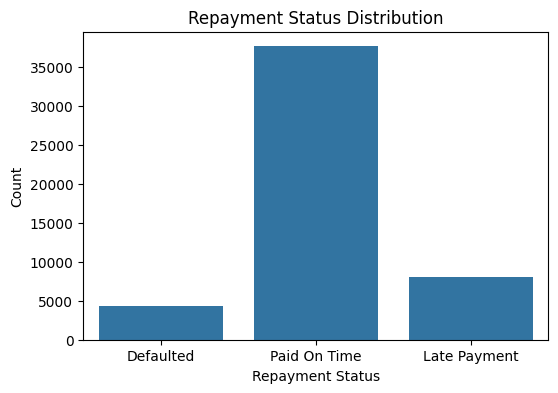

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title('Repayment Status Distribution')
plt.xlabel('Repayment Status')
plt.ylabel('Count')
plt.show()

In [ ]:
df.dtypes

In [6]:
df_fe = df.copy()

# Financial feature engineering
df_fe['Income_to_Purchase_Ratio'] = df_fe['Annual_Income'] / (df_fe['Purchase_Amount'] + 1)
df_fe['Credit_Score_Normalized'] = df_fe['Credit_Score'] / 850

# Age bins
df_fe['Age_Group'] = pd.cut(df_fe['Customer_Age'], 
                            bins=[18,30,45,60,100],
                            labels=['18-30','31-45','46-60','60+'])

df_fe[['Annual_Income','Purchase_Amount','Income_to_Purchase_Ratio']].head(10)

,Annual_Income,Purchase_Amount,Income_to_Purchase_Ratio
0,32293,249,129.172000
1,72774,188,385.047619
2,82207,1610,51.028554
3,92498,120,764.446281
4,32060,1849,17.329730
5,94833,1112,85.204852
6,89772,418,214.252983
7,82341,2117,38.876771
8,80517,286,280.547038
9,108929,244,444.608163


In [ ]:
import pandas as pd
import numpy as np

# Read the data in chunks to avoid memory overflow
chunksize = 5000  # Choose an appropriate chunk size based on memory limits
chunk_list = []

for chunk in pd.read_csv('bnpl_dataset.csv', chunksize=chunksize):
    # Process each chunk
    target_col = chunk.columns[-1]
    
    # Drop high cardinality columns
    keep_cols = [c for c in chunk.columns if chunk[c].nunique() < 100 or chunk[c].dtype != 'object']
    chunk = chunk[keep_cols]

    # One-hot encode categorical columns
    chunk_encoded = pd.get_dummies(chunk, drop_first=True)

    # Convert to numeric values
    chunk_encoded = chunk_encoded.apply(pd.to_numeric, errors='coerce')

    # Store the chunk
    chunk_list.append(chunk_encoded)

# Concatenate all chunks into one DataFrame
df_encoded = pd.concat(chunk_list, axis=0)

# Extract target column
target_col = df_encoded.columns[-1]

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Convert to numpy arrays with more memory-efficient types
X = X.values.astype(np.float32)
y = y.values.astype(np.int32)

# Standardize the data
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_std[X_std == 0] = 1.0
X = (X - X_mean) / X_std

# Split into train and test sets
np.random.seed(42)
indices = np.random.permutation(len(X))
split_idx = int(0.8 * len(X))

X_train, X_test = X[indices[:split_idx]], X[indices[split_idx:]]
y_train, y_test = y[indices[:split_idx]], y[indices[split_idx:]]

# KNN Prediction Logic
def predict_knn(X_tr, y_tr, X_te, k=5):
    preds = []
    for row in X_te:
        diff = X_tr - row
        dist = np.sqrt(np.einsum('ij,ij->i', diff, diff)) 
        nearest = np.argsort(dist)[:k]
        lab = y_tr[nearest].astype(int)
        preds.append(np.bincount(lab).argmax())
    return np.array(preds)

y_pred = predict_knn(X_train, y_train, X_test, k=5)
accuracy = (y_pred == y_test).mean()

print(f"Target identified as: {target_col}")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted']))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()